In [1]:
### import libraries
import pymc3 as pm
import numpy as np
from numpy.lib.stride_tricks import as_strided # to average arrays
import matplotlib.pylab as plt
import seaborn as sns
from math import *
import pandas as pd 
from matplotlib.patches import Circle, Wedge, Polygon
import scipy
import theano.tensor as tt
#the fancy axes
import matplotlib.gridspec as gridspec
# Gaussian Smoothing
from astropy.convolution import Gaussian2DKernel
from astropy.convolution import convolve
from scipy.ndimage import gaussian_filter
from Failure_functions import *
from Forecasting_functions import *
from datetime import datetime, timedelta
from scipy.ndimage import median_filter

The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.


In [2]:
def return_mc(catalog,bins):
    counts, bin_edges = np.histogram(catalog['magnitude'],bins = bins);
    dt_mag = np.diff(bin_edges).min()/2
    mag_vec = bin_edges[:-1]
    mag_count = counts
    mc = mag_vec[mag_count.argmax()]

    return mc


In [3]:
def make_catalog_input(df):
    dict_ = {'time':df['datetime'],'magnitude':df['magnitude']}
    df_tmp = pd.DataFrame(dict_)
    
    path_tmp = '/Users/smarty92/Documents/postDoc_Caltech/project/GMG_codes/GroningenModels/Reservoir_data_MD_paper/Seismicity_catalog/tmp.cvs'   
    df_tmp.to_csv(path_tmp)

In [4]:
def return_newvectime(vectime,ndays):
    new_time_vec = []
    endtime =  data_['timevector_'][-1]
    tstart = data_['timevector_'][0]
    
    while tstart < endtime:
        new_time_vec.append(tstart)
        tstart = tstart + timedelta(days = ndays)

    return pd.to_datetime(new_time_vec)

In [5]:
def interp_cs(cs,timevec_input,timevec_interp):
    x = pd.to_datetime(timevec_input)
    x_inter = pd.to_datetime(timevec_interp)

    x_years = x.year.values + x.day_of_year.values/365.25
    x_interp_years = x_inter.year.values + x_inter.day_of_year.values/365.25

    cs_interp = np.zeros([cs.shape[0],len(timevec_interp)])
    for i in range(cs.shape[0]):
        cs_interp[i,:] = np.interp(x_interp_years,x_years,cs[i,:])
        
        

    return cs_interp


In [6]:
def plot_seismicity_rate(df,timevector_):
    vector_years = timevector_.year.values + timevector_.day_of_year.values/365.25
    vector_years_eq = pd.to_datetime(df['datetime']).dt.year.values + pd.to_datetime(df['datetime']).dt.day_of_year.values/365.25

    rate_ = np.zeros(len(vector_years))
    for i in range(len(vector_years)):
        if i ==0: 
            
            n_ = vector_years_eq[vector_years_eq<=vector_years[i]]
            rate_[i] = len(n_)
            
        else:
            
            t1,t2 = vector_years[i-1],vector_years[i]
            n_ = vector_years_eq[ (vector_years_eq>t1) & (vector_years_eq<=t2)]
            rate_[i] = len(n_)
    fig,ax = plt.subplots(figsize = (6,6))
    dt_ = vector_years[-1] - vector_years[-2]
    fac_ = 1/1

    
    ax.plot(vector_years,fac_*rate_,'-o',color = 'r')
    ax.set_xlabel('Time (years)')
    ax.set_ylabel('Seismicity (M>Mc)')

    
    

In [7]:
def plot_results(SF):
    # -- Training 
    fig,ax = plt.subplots(1, figsize=(15, 8))
    Rpred   = SF.FullModel['Rpred']
    # --  logn : normalization of logp
    logn    = SF.Training['logp']-np.nanmin(SF.Training['logp'])
    logn    = logn/np.nanmax(logn)
    logpn   = 1 - logn
    idx     = np.argsort(logpn)[::-1] #argsort returns the indexes to sort the table
    Rpred_t = np.repeat(SF.FullModel['Time'][:],2)[1:]#each value is repeated twice to plot the yearly values as segments

    #iterate on increasing logpn
    for ii in idx:
      #plot with different grey shades related to the likelihood
      ax.plot(Rpred_t,Rpred[ii,:].repeat(2)[:-1],linewidth=1.0,color='{}'.format(logpn[ii]),alpha=0.05)

    #blue plot is the maximum likelihood model == MAP
    # ax.plot(Rpred_t,Rpred[np.argmin(SF.Training['logp']),:].repeat(2)[:-1],linewidth=2.0,color='b', label='MAP model')
    ax.plot(Rpred_t,np.mean(Rpred,0).repeat(2)[:-1],linewidth=2.0,color='b', label='MAP model')

    #red plot is the observed seismicity catalog
    Robs   = SF.FullModel['Robs']
    Robs_t = np.repeat(SF.Catalogue['Dates'],2)[1:]
    # ax.plot(Robs_t,median_filter(Robs.repeat(2),3),'r--', label='historical data')
    ax.plot(Robs_t,Robs.repeat(2)[:-1],'r--', label='historical data')


    #vertical blue lines denote the training period
    ax.axvline(SF.training_period[0], label='history matching period',c='darkblue')
    ax.axvline(SF.training_period[1],c='darkblue')

    #vertical red lines denote the training period
    ax.axvline(SF.validation_period[0], label='testing period',c='darkred')
    ax.axvline(SF.validation_period[1],c='darkred')

    dt = (SF.validation_period[1] - SF.training_period[0]) / 2
    dt = (Robs_t.max() - Robs_t.min())/10

    ax.set_xlim([SF.training_period[0] - dt ,SF.validation_period[1] + dt])
    ax.set_xlim([Robs_t.min() - dt ,Robs_t.max() + dt])
    
    ax.set_ylim(0,1.5*median_filter(Robs.repeat(2),3).max())
    # ax.set_ylim(0,)

    
    
    ax.set_ylabel('Earthquake rate')
    ax.set_xlabel('Time')
    #ax.set_title('Training med(logp)={:.3f}, Validation med(logp)={:.3f}'.format(np.median(SF.Training['logp']),np.median(SF.Validation['logp'])))
    ax.set_title('Training med(logp)={:.3f}'.format(np.median(SF.Training['logp'])))
    ax.legend(loc='upper left')



In [8]:
## load stres model output
## Samson version

# Load the Coulomb Stress data and average yearly
import pickle

file_ = '/Users/smarty92/Documents/postDoc_Caltech/project/draft_paper/MD/processed_data/final_model_results_2500_short/cluster_0_example.pkl'
file_ = open(file_, 'rb')
data_ = pickle.load(file_)

In [9]:
# process the catalog and store it into a format readable by the MCMC code
catalog_= data_['catalog']
Mc = return_mc(catalog_,bins = 20)
print('The (local) magnitude of completeness for the catalog given in input is: ' + str(round(Mc,2)))
make_catalog_input(catalog_)

The (local) magnitude of completeness for the catalog given in input is: 0.34


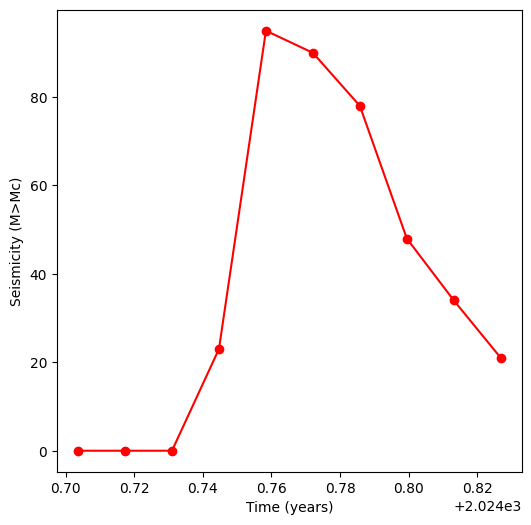

In [10]:
## With the functions return_newvectime and interp_cs you can resample the calculated Coulomb stresses and pore-pressure changes
new_vec_time = return_newvectime(data_['timevector_'],5) ## the second argument is for the time step, in days, for the resampling
plot_  =  plot_seismicity_rate(catalog_.loc[catalog_['magnitude']>Mc],new_vec_time) ## plot the seismicty above Mc
cs_interp = interp_cs(data_['max_CS'],data_['timevector_'],new_vec_time) ## Coulomb stress resampling

In [11]:
# Load the Coulomb Stress data and define
import pickle

kernel = Gaussian2DKernel(3)
dC_raw = cs_interp.reshape(data_['X_'].shape[0],data_['Y_'].shape[1],-1)
dC = np.array([convolve(dC_raw[:,:,ii],kernel,nan_treatment='fill') for ii in range(dC_raw.shape[-1])]).transpose((1, 2, 0)) ## smoothing of the Coulomb stresses >> help to stabilize the inversion b/c of the exponential 
data_time = new_vec_time


time_cs = []

for i in range(len(data_time)):
    t_ = pd.to_datetime(data_time[i])
    t_y = t_.year + t_.day_of_year/365
    time_cs.append(t_y)

time_cs = np.asarray(time_cs)


dC_y ={} # Disctionnary to store the yearly data
dC_y['Coulomb'] = dC / 1e6
dC_y['Time']    = time_cs


# # Load the seismicity catalog
catalog_file = '/Users/smarty92/Documents/postDoc_Caltech/project/GMG_codes/GroningenModels/Reservoir_data_MD_paper/Seismicity_catalog/tmp.cvs'
# # Define the completion magnitude to use


In [12]:
## range in log. for r,Qsig0,ta,DeltaSc
prior_min=[-4,-4,-10,0] ## good for permea = 5e-12
prior_max=[2,2,0,5] ## good for permea = 5e-12

dt_ = (time_cs[-1] - time_cs[-2])
fac_ = 1 / dt_
tinf,tsup = 1,10000


ev1,ev2 = np.log10(1e-2)+np.log10(dt_),np.log10(1e2)+np.log10(dt_)
sig1,sig2 = np.log10(1e-3),np.log10(1e-0)
s1,s2 = np.log10(1e-10),np.log10(1e0)
t1,t2 = np.log10(tinf) + np.log10(fac_),np.log10(tsup) + np.log10(fac_)


prior_min=[ev1,sig1,s1,t1]
prior_max=[ev2,sig2,s2,t2] 


# Choose the failure function to be used
## TRS == Treshold Rate and State --> Heimisson et al., 2022
## RS == Classic Rate and State --> Dieterich., 1994
## ET == Extreme Threshold --> Bourne et al., 2017
## GF == Gaussian Failure --> Smith et al., 2022

Failure_function = 'TRS'
# LogLikelihood = 'Poisson'
LogLikelihood = 'Gaussian'

if Failure_function =='TRS':
    method = ThresholdRateAndState_logSampled(prior_min=prior_min,prior_max=prior_max)
    labels = ['$r$ (evts/year)','$A \sigma$ (MPa)','$\Delta S_c$ (MPa)','$t_a$ (years)']
    LLK = LogLikelihood # log likelihood
    
elif Failure_function =='RS':
    method = ClassicRateAndState_logSampled(prior_min=prior_min,prior_max=prior_max) 
    labels = ['$r$ (evts/year)','$A \sigma$ (MPa)','$t_a$ (years)']
    LLK = 'Gaussian' # log likelihood

elif Failure_function =='ET':
    method = ExtremeThreshold() 
    labels = ['$\beta_0$','$\beta_1$','$\beta_2$']
    LLK = LogLikelihood # log likelihood

elif Failure_function =='GF':
    method = GaussianFailure()
    labels = ['$\beta_0$','$\beta_1$','$\beta_2$']
    LLK = LogLikelihood # log likelihood

In [13]:
# Define parameters for the inversions
# Num_samples = 20000 # samples for the MCMC inversion
# Warmup_percentage = 25 # percentage burn-in samples
# Num_chains = 10 #number of chains for the inversion

Num_samples = 20000
Warmup_percentage = 50
Num_chains = 10

t1 = round(dC_y['Time'].min(),4)
t2 = round(dC_y['Time'].max(),4)
dt = (t2-t1)
ratio_ = 0.66
ts = t1
tt = t1 + ratio_*dt

Training = [ts,tt] # Training period
# Validation = [ts,tt] # Validation period 
Validation = [tt,t2] # Validation period

In [14]:
# Run the MCMC inversion
# Create the forecasting object
SF = SeismicityForecasting(method,catalog_file,dC_y,num_samples=Num_samples,warmup_percentage=Warmup_percentage,num_chains=Num_chains,Mc=Mc)# load the forecasting model and give the parameters)
# Run the inference
SF.run(training=Training,validation=Validation,LLK=LLK)

========= Training - Running MCMC =========


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
Multiprocess sampling (10 chains in 4 jobs)
CompoundStep
>Metropolis: [θ4]
>Metropolis: [θ3]
>Metropolis: [θ2]
>Metropolis: [θ1]
The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
The version of PyMC you are usi

Sampling 10 chains for 10_000 tune and 10_000 draw iterations (100_000 + 100_000 draws total) took 50 seconds.
The rhat statistic is larger than 1.4 for some parameters. The sampler did not converge.
The estimated number of effective samples is smaller than 200 for some parameters.


Saving trace data
========= Training - Determine R_Pred,Betas,logp =========
Forecast Parameters :
<MultiTrace: 10 chains, 10000 iterations, 8 variables>
chains
10
draws
10000
samples
1000
========= Validation - Determine R_Pred,Betas,logp =========
========= Full-time Evolution - Determine R_Pred =========
Forecast Parameters :
<MultiTrace: 10 chains, 10000 iterations, 8 variables>
chains
10
draws
10000
samples
1000


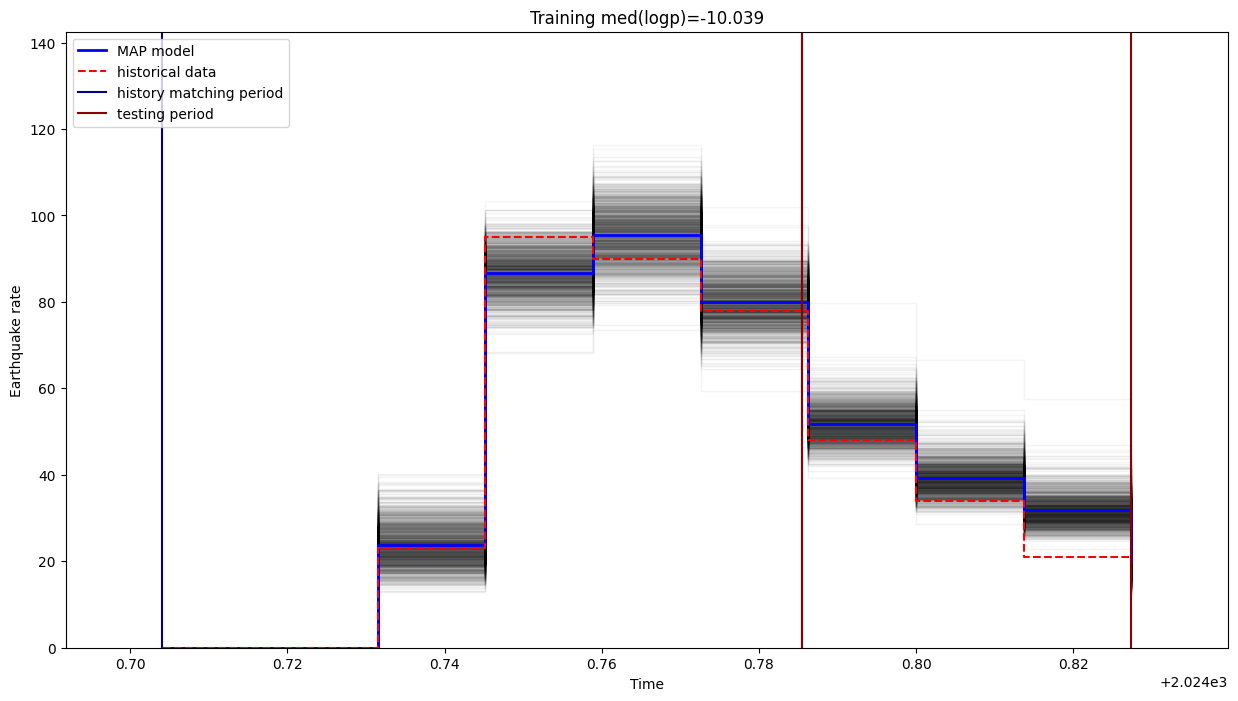

In [15]:
plot_results(SF)

In [16]:
########################                ##########################
#  In this part we will extract various information of the MCMC inversion from SF
#   From this information we obtain 
# 1 -- the 95% confidence interval based on the parameters estimates
# 2 -- the spatial forecast
########################                ##########################

In [17]:
import math
from scipy.stats import poisson
import datetime

def int_conf(mat_pred,logp):
    
    mat_pred_sel = mat_pred[logp>0.95,:]
    mat_pred_up = mat_pred_sel.max(0)
    mat_pred_min = mat_pred_sel.min(0)
    
    Robs_up = []
    Robs_low = []

    for i in range(len(mat_pred_up)):
    
        mu = int(math.ceil(mat_pred_up[i]))
        x = np.arange(poisson.ppf(0.01, mu),
                  poisson.ppf(0.99, mu))
        dist_ = poisson.pmf(x, mu).cumsum()
        
        
        if (len(dist_)>0) & (mu >= 1):
    
            xn = np.linspace(poisson.ppf(0.01, mu),
                  poisson.ppf(0.99, mu),50)
            
            dist_n = np.interp(xn,x,dist_)
            up = xn[dist_n>=0.95][0]
            Robs_up.append(up)
            
        else:
            # Robs_up.append(mat_pred_up[i])
            Robs_up.append(0)
            

    for i in range(len(mat_pred_min)):
        
    
        mu = int(math.ceil(mat_pred_min[i]))
        x = np.arange(poisson.ppf(0.01, mu),
                  poisson.ppf(0.99, mu))
        dist_ = poisson.pmf(x, mu).cumsum()
        
        
        if (len(dist_)>0) & (mu >= 1):
    
            xn = np.linspace(poisson.ppf(0.01, mu),
                  poisson.ppf(0.99, mu),50)

            dist_n = np.interp(xn,x,dist_)
            dist_b_n =  1 - dist_n
            try:
                low = xn[dist_b_n>=0.95][-1]
                Robs_low.append(low)
            except:
                Robs_low.append(0)
                
                
        else:
            # Robs_low.append(mat_pred_min[i])
            Robs_low.append(0)

    return(np.vstack([np.array(Robs_up),np.array(Robs_low)]).T)
    
def decimal_year_to_datetime(decimal_years):
    datetimes = []
    for dy in decimal_years:
        year = int(dy)
        rem = dy - year
        # Days in year (handle leap years)
        start = datetime.datetime(year, 1, 1)
        if year % 4 == 0 and (year % 100 != 0 or year % 400 == 0):
            days_in_year = 366
        else:
            days_in_year = 365
        # Convert remainder into timedelta
        dt = start + datetime.timedelta(days=rem * days_in_year)
        datetimes.append(dt)
    return datetimes


In [20]:
###### define the data ########

param = SF.Training['betas'][np.argmin(SF.Training['logp']),:]
Rpred_   = SF.FullModel['Rpred']    # --  logn : normalization of logp
logn    = SF.Training['logp']-np.nanmin(SF.Training['logp'])
logn    = logn/np.nanmax(logn)
logpn   = 1 - logn
idx     = np.argsort(logpn)[::-1] #argsort returns the indexes to sort the table
Rpred_t = SF.FullModel['Time'] #each value is repeated twice to plot the yearly values as segments
Best_model = Rpred_[np.argmin(SF.Training['logp']),:]
Robs   = SF.FullModel['Robs']
Robs_t = SF.Catalogue['Dates']


############ spatial forecast


file_coor = data_['X_']
X_,Y_ = data_['X_'],data_['Y_']
dCp = dC_y['Coulomb']

beta1,beta2,beta3,beta4 = param
beta3 =beta3
K = np.exp( (dCp - beta3) / beta2)
K[np.where(dCp<beta3)] = 0
intgr_K = np.cumsum(K, axis = -1)
R_pred_mat = beta1 * K / ((1/beta4)*intgr_K + 1) 

############ 95% confidence interval 

## 95% interval confidence up and low
int_conf_ = int_conf(Rpred_,logpn)
Robs_up = int_conf_[:,0]
Robs_low = int_conf_[:,1]

t_obs = decimal_year_to_datetime(Robs_t.repeat(2)[1:])
t_pred = decimal_year_to_datetime(Rpred_t.repeat(2)[1:])

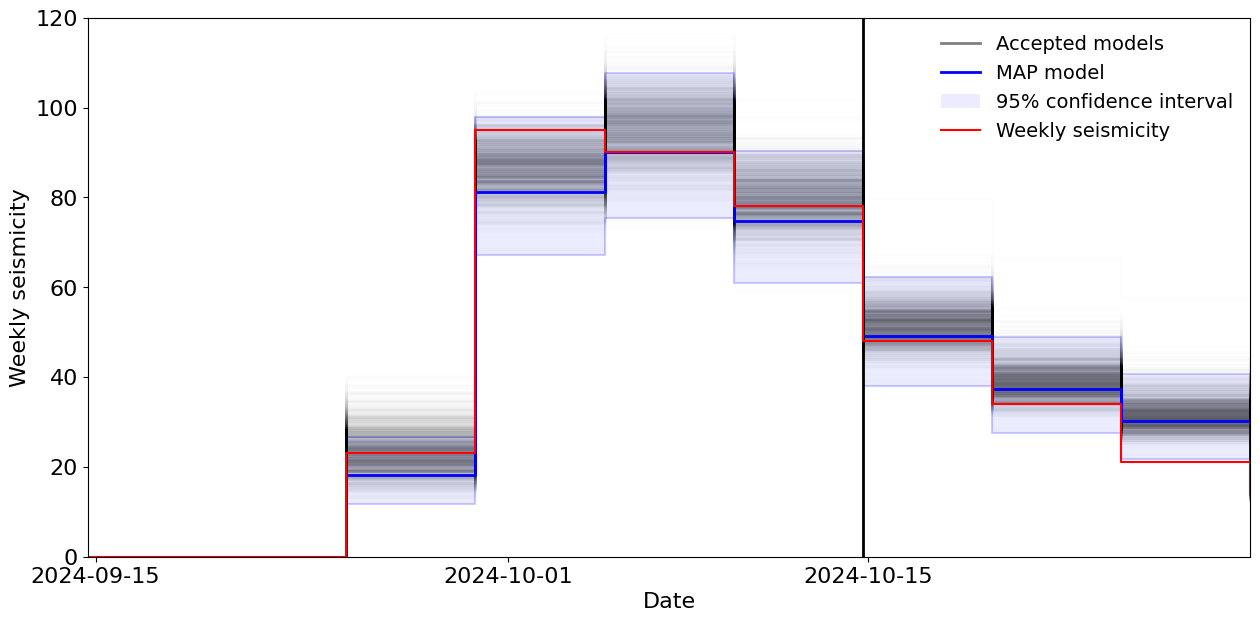

In [21]:
########## temporal forecast
fig,ax = plt.subplots(figsize = (15,7))
alpha = 1


ax.plot(t_pred,Robs_up.repeat(2)[:-1],'b-',alpha = 0.2)
ax.plot(t_pred,Robs_low.repeat(2)[:-1],'b-',alpha = 0.2)
for i in range(Rpred_.shape[0]):
    ax.plot(t_pred,Rpred_[i,:].repeat(2)[:-1],'k-',linewidth = 2,alpha = 0.0075)
    if i == 0 :
        ax.plot(np.zeros(Rpred_[i,:].repeat(2)[:-1].size),Rpred_[i,:].repeat(2)[:-1],'k-',linewidth = 2,label='Accepted models',alpha = 0.5)


ax.plot(t_pred,Best_model.repeat(2)[:-1],'b-',linewidth = 2,label = 'MAP model',alpha = alpha)

ax.fill_between(t_pred,Robs_low.repeat(2)[:-1],Best_model.repeat(2)[:-1],facecolor = 'b',alpha = 0.075,label = '95% confidence interval')
ax.fill_between(t_pred,Best_model.repeat(2)[:-1],Robs_up.repeat(2)[:-1],facecolor = 'b',alpha = 0.075)

ax.set_xlim(t_obs[0],t_obs[-1])
ax.set_ylim(0,120)

ind  = int(len(t_pred)*0.66)
x_ = 120

ax.vlines(t_pred[ind],0,x_,'k',linewidth = 2)
ax.plot(t_obs,Robs.repeat(2)[:-1],'r-', label='Weekly seismicity',linewidth = 1.5,alpha = 1)

ax.tick_params(axis = 'both',labelsize = 16)
ax.set_xlabel('Date',fontsize = 16)
ax.set_ylabel('Weekly seismicity',fontsize = 16)
# Get current tick positions
ticks = ax.get_xticks()

# Keep every second tick
ax.set_xticks(ticks[::2])
ax.legend(loc = 'upper right',fontsize = 14,facecolor='white', framealpha=1,edgecolor = 'white')


Text(-102.41271092121909, 31.9682108, '2.5 km')

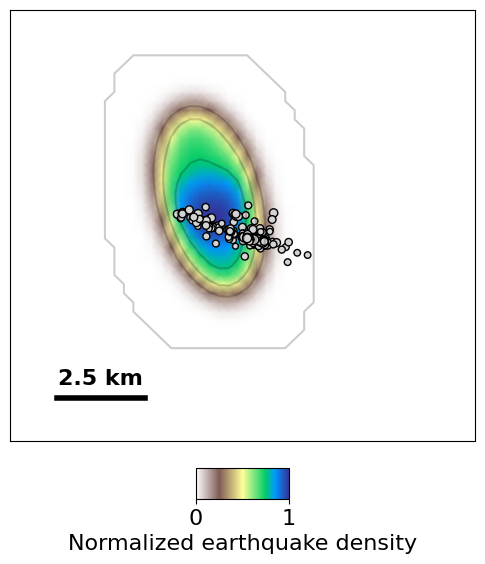

In [22]:
############### spatial forecast

fig,ax = plt.subplots(figsize = (6,7))
cmap = 'terrain_r'
vmax = 1 * R_pred_mat[:,:,:].sum(axis = -1).max()
sigma = 1
levels = 3

dens = gaussian_filter(R_pred_mat[:,:,:].sum(axis = -1),sigma = sigma) ## smooth by 1 standard deviation
dens = dens/dens.max()

vmax = 1

p1 = ax.pcolormesh(X_,Y_,dens,cmap = cmap,shading='gouraud',vmax = vmax)
ax.contour(X_,Y_,dens,levels = levels,colors = 'k',alpha = 0.2)
ax.scatter(catalog_['longitude'],catalog_['latitude'],marker = 'o',
           s = 20*(2**catalog_['magnitude']),
           c = 'lightgray',
          edgecolors = 'black')
p2 = ax.scatter(0,0,marker = 'o',s = 25,c = 'lightgray',
          edgecolors = 'black',label = 'seismicity')
ax.set_xlim(X_.min(),X_.max())
ax.set_xticks([])
ax.set_yticks([])
cbar  = plt.colorbar(p1, orientation = 'horizontal', shrink = 0.2, aspect = 3, pad=0.05,ticks=[0, 1])
cbar.set_label('Normalized earthquake density',fontsize = 16)
cbar.ax.tick_params(labelsize=16)
cbar.set_ticks([0,1])
ax.set_ylim(31.955,Y_.max())

dx_ = (X_.max()  -  X_.min())
dx_5 = 2.5/(111.32 * np.cos(Y_.max()*np.pi/180))
dy_ = Y_.max() - 31.955

pos_y = 31.955 + (1/10)*dy_
pos_x_1 = X_.min() + (1/10)*dx_
pos_x_2 = pos_x_1 + dx_5

# draw the scale bar
ax.plot([pos_x_1, pos_x_2], [pos_y, pos_y],
        '-', linewidth=4, color='k')

# midpoint of the line
x_mid = (pos_x_1 + pos_x_2) / 2

# small vertical offset (relative to axis height)
y_offset = 0.02 * (ax.get_ylim()[1] - ax.get_ylim()[0])

# place text centered above
ax.text(x_mid, pos_y + y_offset,
        '2.5 km',
        ha='center', va='bottom',weight = 'semibold',size=16)



In [24]:
import pickle
dict_ = {'X_':X_, 'Y_':Y_, 'spatial_forecast':dens, 't_pred':t_pred, 't_obs':t_obs,
 'Seismicity_rate_obs':Robs, 'temporal_best_model':Best_model, 
 '95_conf-interv':np.array([Robs_low,Robs_up]), 'catalog':data_['catalog'], 'Coulomb_Stress':dC_y}
path_ = '/Users/smarty92/Documents/postDoc_Caltech/project/draft_paper/MD/open_research_section/clust_0_short.pkl'
with open(path_, 'wb') as f:
    pickle.dump(dict_, f)